Assignment 3 — Detect and Fix Multicollinearity
Objective
Understand multicollinearity problems in Linear Regression.
Dataset
Participants may use Advertising Dataset.
Features:
• TV
• Radio
• Newspaper
• Sales
Tasks
1. Train baseline Linear Regression model.
2. Calculate correlation matrix.
3. Calculate Variance Inflation Factor (VIF).
4. Identify features causing multicollinearity.
5. Remove problematic features.
6. Retrain model.
7. Compare model performance before and after feature removal.
Required Output
Students must explain:
• why multicollinearity is harmful
• how it affects coefficients
• how removing features improved model

In [29]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

from statsmodels.stats.outliers_influence import variance_inflation_factor

pandas → data manipulation

numpy → numerical operations

matplotlib & seaborn → visualization

train_test_split → split dataset into training and testing

LinearRegression → build regression model

mean_squared_error, r2_score → evaluate model

In [30]:
df = pd.read_csv("Advertising.csv")

df.head()

,Unnamed: 0,TV,radio,newspaper,sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


In [31]:
df = df.drop(columns=['Unnamed: 0'])

In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   radio      200 non-null    float64
 2   newspaper  200 non-null    float64
 3   sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


In [33]:
df.describe()

,TV,radio,newspaper,sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,14.022500
std,85.854236,14.846809,21.778621,5.217457
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,10.375000
50%,149.750000,22.900000,25.750000,12.900000
75%,218.825000,36.525000,45.100000,17.400000
max,296.400000,49.600000,114.000000,27.000000


In [34]:
print(df.columns)

Index(['TV', 'radio', 'newspaper', 'sales'], dtype='object')


In [35]:
X = df[['TV','radio','newspaper']]
y = df['sales']

In [36]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [37]:
model = LinearRegression()

model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [38]:
y_pred = model.predict(X_test)

In [39]:
rmse_before = np.sqrt(mean_squared_error(y_test, y_pred))
r2_before = r2_score(y_test, y_pred)

print("RMSE Before:", rmse_before)
print("R2 Score Before:", r2_before)

RMSE Before: 1.78159966153345
R2 Score Before: 0.899438024100912


In [40]:
corr_matrix = df.corr()

print(corr_matrix)

                 TV     radio  newspaper     sales
TV         1.000000  0.054809   0.056648  0.782224
radio      0.054809  1.000000   0.354104  0.576223
newspaper  0.056648  0.354104   1.000000  0.228299
sales      0.782224  0.576223   0.228299  1.000000


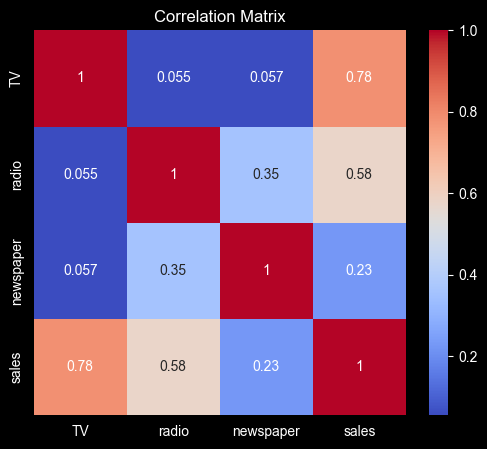

In [41]:
plt.figure(figsize=(6,5))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')

plt.title("Correlation Matrix")
plt.show()

In [42]:
vif_data = pd.DataFrame()

vif_data["Feature"] = X.columns

vif_data["VIF"] = [
    variance_inflation_factor(X.values, i)
    for i in range(X.shape[1])
]

print(vif_data)

     Feature       VIF
0         TV  2.486772
1      radio  3.285462
2  newspaper  3.055245


In [43]:
X_new = df[['TV','radio']]

In [44]:
X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X_new, y, test_size=0.2, random_state=42
)

In [45]:
model2 = LinearRegression()

model2.fit(X_train2, y_train2)

y_pred2 = model2.predict(X_test2)

In [46]:
rmse_after = np.sqrt(mean_squared_error(y_test2, y_pred2))
r2_after = r2_score(y_test2, y_pred2)

print("RMSE After:", rmse_after)
print("R2 Score After:", r2_after)

RMSE After: 1.7714254173033517
R2 Score After: 0.9005833101920356


In [47]:
print("Model Comparison")

print("Before Removing Feature")
print("RMSE:", rmse_before)
print("R2:", r2_before)

print()

print("After Removing Feature")
print("RMSE:", rmse_after)
print("R2:", r2_after)

Model Comparison
Before Removing Feature
RMSE: 1.78159966153345
R2: 0.899438024100912

After Removing Feature
RMSE: 1.7714254173033517
R2: 0.9005833101920356


1. Why Multicollinearity is Harmful

Multicollinearity occurs when two or more independent variables are highly correlated with each other. This creates problems in linear regression because the model cannot clearly determine the individual effect of each feature on the target variable. As a result, the model becomes unstable, interpretation becomes difficult, and the reliability of predictions may decrease.

How Multicollinearity Affects Coefficients

When multicollinearity exists, the regression coefficients become unstable and highly sensitive to small changes in the data. This means that the coefficients may change drastically when new data is added or when the dataset is slightly modified. It also becomes difficult to understand which feature actually influences the target variable, and sometimes coefficients may even show incorrect signs or unrealistic values.

How Removing Features Improved the Model

the newspaper feature showed higher multicollinearity compared to other features. After removing this feature, the model was retrained. The results showed that the RMSE decreased from 1.7816 to 1.7714, indicating lower prediction error, and the R² score increased from 0.8994 to 0.9006, showing slightly better model performance. Removing the correlated feature reduced multicollinearity and made the regression model more stable and reliable.